# 3D observable error plot

3D companion to `plot.ipynb` for the complete `r = [1, 2, 3, 7]` cases. The z-axis uses the same observable error definition as the active 2D notebook: `log10(abs(observable / N - exact))`.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, registers 3D projection
from matplotlib.lines import Line2D

%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 14})
plt.rcParams["text.usetex"] = True
# plt.rcParams["mathtext.fontset"] = "custom"
# plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

SAVE_PDF = 1
SHOW_ZNE_TO_ZERO = True

N = 20
T = 1.0
seed = 43

r_list = np.array([2, 3, 4, 5])
noise_list = np.array([1.0, 3.375, 8.0, 15.625])
noise_with_zero = noise_list.copy()
joint_noise = np.flip(noise_list)

SAMPLE_SUBDIR = "sample_J1_h1_T1_r2_5_noise_scan"
EXACT_FILE = Path("exact_results") / "exact_N_20_J_1_h_1_T_1_r_10000.json"

for candidate in [Path('.'), Path('..'), Path('../..'), Path('tensor_network_numerics')]:
    if (candidate / 'data' / f'N{N}' / SAMPLE_SUBDIR).exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(f'Could not locate tensor_network_numerics/data/N{N}/{SAMPLE_SUBDIR}')

SAMPLE_DIR = ROOT / 'data' / f'N{N}' / SAMPLE_SUBDIR
EXACT_PATH = ROOT / 'data' / f'N{N}' / EXACT_FILE
exact_data = json.loads(EXACT_PATH.read_text())
exact = float(exact_data['expectation_real']) / N

pdf_dir = ROOT / "figures"
pdf_name_3d = pdf_dir / f"observable_error_3d_r_noise_N_{N}_seed_{seed}.pdf"

print('SAMPLE_DIR:', SAMPLE_DIR)
print('EXACT_PATH:', EXACT_PATH)
print('exact per site:', exact)
print('r_list:', r_list)
print('noise_list:', noise_with_zero)
print('1D joint path noise:', joint_noise)


SAMPLE_DIR: ../../data/N20/sample_J1_h1_T1_r2_5_noise_scan
EXACT_PATH: ../../data/N20/exact_results/exact_N_20_J_1_h_1_T_1_r_10000.json
exact per site: 0.3048683435316751
r_list: [2 3 4 5]
noise_list: [ 1.     3.375  8.    15.625]
1D joint path noise: [15.625  8.     3.375  1.   ]


In [2]:
def format_float_for_filename(value):
    text = f"{value:g}"
    return text.replace("-", "m").replace(".", "p")


def result_file_path(r, noise, T=T, N=N, seed=seed):
    noise_text = format_float_for_filename(noise)
    stem = f"r_{int(r)}_T_{format_float_for_filename(T)}_noise_{noise_text}_seed_{seed}"
    p = SAMPLE_DIR / f"{stem}.txt"
    if p.exists():
        return p

    # Historical files sometimes omitted T when T=1.
    legacy = SAMPLE_DIR / f"r_{int(r)}_noise_{noise_text}_seed_{seed}.txt"
    if legacy.exists():
        return legacy

    raise FileNotFoundError(f'Expected result file not found for r={r}, noise={noise}: {p}')


def read_observable_per_site(r, noise):
    p = result_file_path(r, noise)
    txt = p.read_text(encoding='utf-8').strip()
    val_str = txt.split('=')[-1].strip() if '=' in txt else txt
    return float(val_str) / N


def observable_error(r, noise):
    return np.log10(abs(read_observable_per_site(r, noise) - exact))


def get_richardson_coeffs(x_array, p=1):
    """Return coefficients that extrapolate f(x) to x=0.

    The coefficients satisfy sum_i c_i x_i^k = delta_{k0} for k=0..n-1.
    Use x = 1 / r**2 for Trotter-step extrapolation and x = noise for ZNE.
    """
    x_array = np.asarray(x_array, dtype=float)
    n = len(x_array)
    A = np.zeros((n, n))
    for i in range(n):
        A[i, :] = x_array ** (i * p)
    b = np.zeros(n)
    b[0] = 1
    return np.linalg.solve(A, b)


def richardson_extrapolate(values, coeffs):
    values = np.asarray(values, dtype=float)
    coeffs = np.asarray(coeffs, dtype=float)
    return np.tensordot(values, coeffs, axes=([-1], [0]))


def get_trotter_richardson_coeffs(r_array):
    """Use the paper/plot.ipynb coefficient lists when available."""
    r_key = tuple(int(r) for r in np.asarray(r_array))
    known_coeffs = {
        (1, 2): np.array([1/3, -4/3]),
        (1, 2, 4): np.array([1/45, -4/9, 64/45]),
        (1, 2, 6): np.array([1/105, -1/6, 81/70]),
        (1, 2, 3, 7): np.array([-1/1152, 64/675, -729/1600, 117649/86400]),
        (2, 3, 4, 5): np.array([-16/315, 729/560, -1024/189, 15625/3024]),
    }
    if r_key in known_coeffs:
        return known_coeffs[r_key]

    parameter = 1 / np.asarray(r_array, dtype=float) ** 2
    return get_richardson_coeffs(parameter, p=1)


observable_grid = np.array([
    [read_observable_per_site(r, noise) for r in r_list]
    for noise in noise_with_zero
])
error_grid = np.log10(np.abs(observable_grid - exact))

joint_values = np.array([
    read_observable_per_site(r, noise)
    for r, noise in zip(r_list, joint_noise)
])
joint_errors = np.log10(np.abs(joint_values - exact))

trotter_parameter = 1 / np.asarray(r_list, dtype=float) ** 2
trotter_coeffs = get_trotter_richardson_coeffs(r_list)
noise_rows = ~np.isclose(noise_with_zero, 0)
has_noise_zero = bool(np.any(~noise_rows))
noise_zero_index = int(np.where(~noise_rows)[0][0]) if has_noise_zero else None
noise_coeffs = get_richardson_coeffs(noise_with_zero[noise_rows], p=1)

extrapolated_1d = richardson_extrapolate(joint_values, trotter_coeffs)
noise_free_extrapolated = (
    richardson_extrapolate(observable_grid[noise_zero_index], trotter_coeffs)
    if has_noise_zero
    else np.nan
)
fixed_noise_extrapolated_by_noise = richardson_extrapolate(observable_grid[noise_rows], trotter_coeffs)
extrapolated_2d = richardson_extrapolate(fixed_noise_extrapolated_by_noise, noise_coeffs)
extrapolated_1d_error = np.log10(abs(extrapolated_1d - exact))
extrapolated_2d_error = np.log10(abs(extrapolated_2d - exact))

# Same 2D extrapolation, but in the reverse order. This is a useful consistency check.
zne_extrapolated_by_r = richardson_extrapolate(observable_grid[noise_rows].T, noise_coeffs)
zne_errors_by_r = np.log10(np.abs(zne_extrapolated_by_r - exact))
extrapolated_2d_reverse = richardson_extrapolate(zne_extrapolated_by_r, trotter_coeffs)

print('observable_grid shape:', observable_grid.shape)
print('error_grid shape:', error_grid.shape)
print('z range:', error_grid.min(), error_grid.max())
print('trotter_parameter:', trotter_parameter)
print('trotter_coeffs:', trotter_coeffs)
print('noise_rows:', noise_rows)
print('has_noise_zero:', has_noise_zero)
print('noise_coeffs:', noise_coeffs)
print('Exact value:', exact)
print('1D extrapolated value:', extrapolated_1d)
print('Noise-free extrapolated value:', noise_free_extrapolated)
print('2D extrapolated value:', extrapolated_2d)
print('2D extrapolated value, reverse order:', extrapolated_2d_reverse)
print('1D extrapolated error:', extrapolated_1d_error)
print('2D extrapolated error:', extrapolated_2d_error)
print('ZNE extrapolated values by r:', zne_extrapolated_by_r)
print('ZNE extrapolated errors by r:', zne_errors_by_r)
print('joint_errors:', joint_errors)


observable_grid shape: (4, 4)
error_grid shape: (4, 4)
z range: -1.8918294185665412 -0.5686067313077554
trotter_parameter: [0.25       0.11111111 0.0625     0.04      ]
trotter_coeffs: [-0.05079365  1.30178571 -5.41798942  5.16699735]
noise_rows: [ True  True  True  True]
has_noise_zero: False
noise_coeffs: [ 1.735107   -0.92896333  0.21362112 -0.01976478]
Exact value: 0.3048683435316751
1D extrapolated value: 0.8762436302910854
Noise-free extrapolated value: nan
2D extrapolated value: 0.40397112727717827
2D extrapolated value, reverse order: 0.4039711272771785
1D extrapolated error: -0.24307854774068183
2D extrapolated error: -1.0039141462379204
ZNE extrapolated values by r: [0.65000264 0.50067314 0.45227758 0.43267936]
ZNE extrapolated errors by r: [-0.46201189 -0.70817667 -0.83147531 -0.8934317 ]
joint_errors: [-0.77966085 -1.10315235 -1.01462588 -1.56174797]


Saved PDF to ../../figures/observable_error_3d_r_noise_N_20_seed_43.pdf


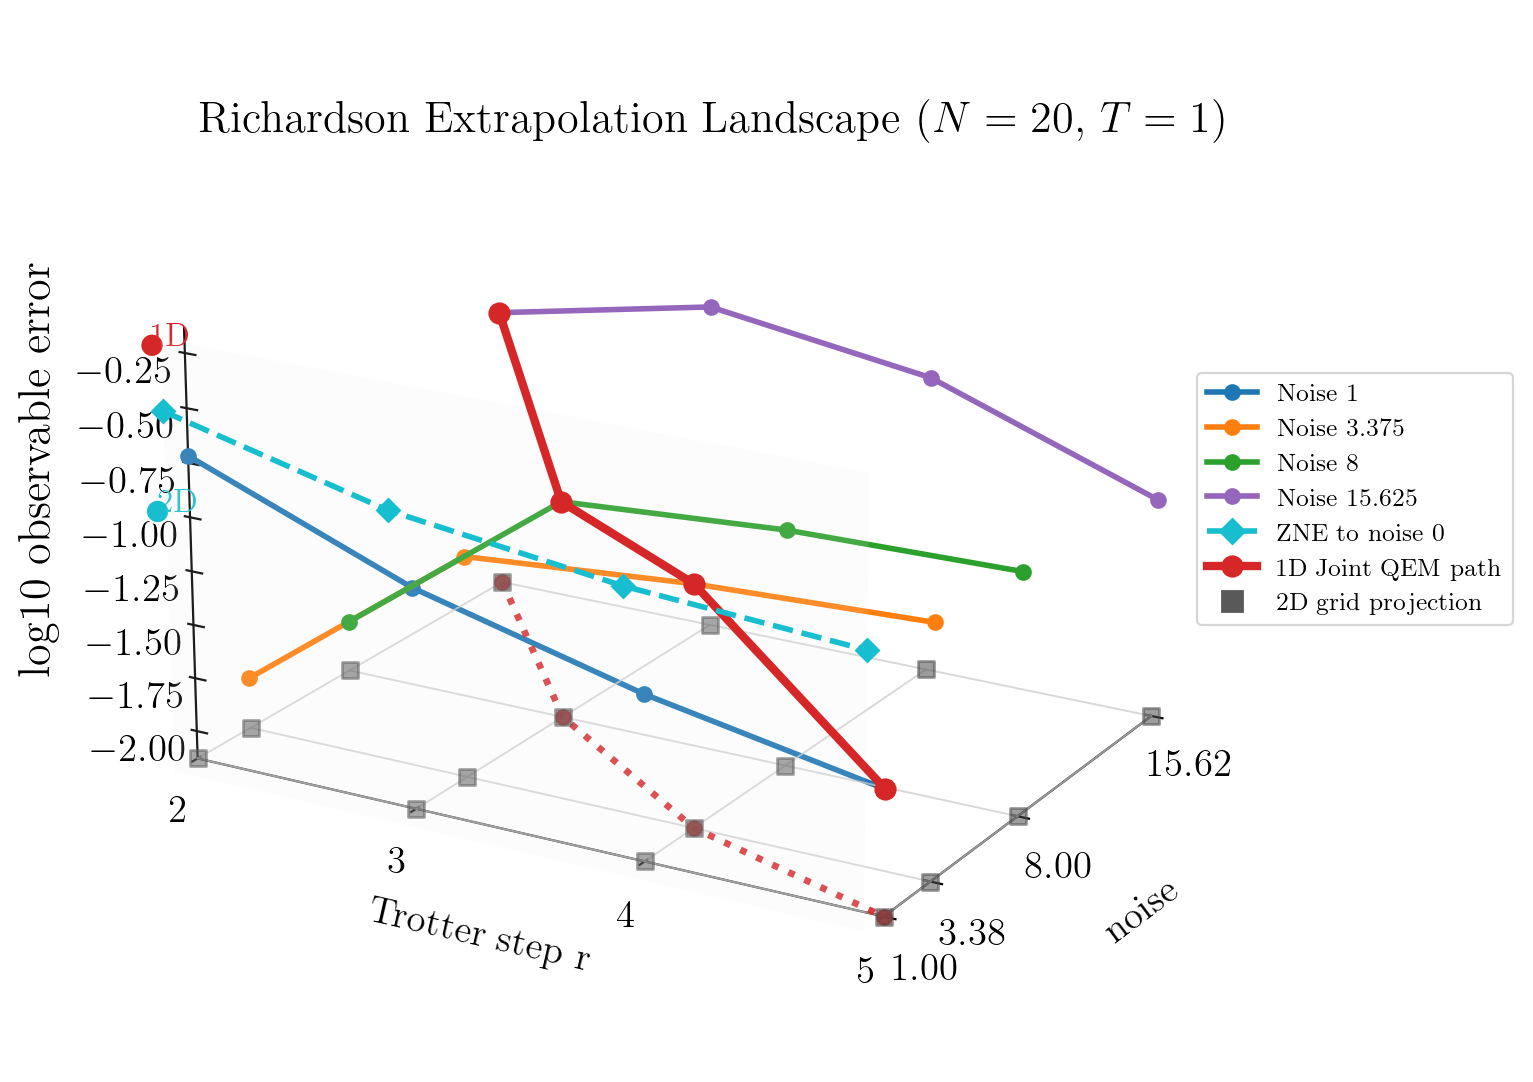

In [3]:
R, Noise = np.meshgrid(r_list, noise_with_zero)

z_span = np.ptp(error_grid)
z_floor = np.nanmin(error_grid) - (0.18 * z_span if z_span > 0 else 0.1)
z_top = max(
    np.nanmax(error_grid),
    np.nanmax(zne_errors_by_r),
    extrapolated_1d_error,
    extrapolated_2d_error,
) + 0.08 * max(z_span, 1.0)

fig = plt.figure(figsize=(9.5, 6.6))
fig.patch.set_alpha(0.0)
ax = fig.add_subplot(111, projection='3d')
ax.patch.set_alpha(0.0)

# Keep the 3D coordinate frame, but remove the upright pane surfaces.
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.fill = False
    axis.pane.set_alpha(0.0)
    axis.pane.set_edgecolor((1, 1, 1, 0))
    axis._axinfo['grid']['color'] = (1, 1, 1, 0)
    axis._axinfo['grid']['linewidth'] = 0.0
    axis._axinfo['axisline']['color'] = (0.35, 0.35, 0.35, 0.85)
    axis._axinfo['tick']['color'] = (0.18, 0.18, 0.18, 1.0)

noise_colors = ['C0', 'C1', 'C2', 'C4', 'C5'][:len(noise_with_zero)]

# Vertical comparison plane at noise = 0.
r_plane, z_plane = np.meshgrid(
    np.linspace(r_list.min(), r_list.max(), 2),
    np.linspace(z_floor, z_top, 2),
)
noise_zero_plane = np.zeros_like(r_plane)
ax.plot_surface(
    r_plane,
    noise_zero_plane,
    z_plane,
    color='0.92',
    alpha=0.12,
    linewidth=0,
    shade=False,
    zorder=0,
)

# Fixed-noise slices: these are the separated 3D versions of the lines in plot.ipynb.
for noise, color, z_values in zip(noise_with_zero, noise_colors, error_grid):
    ax.plot(
        r_list,
        np.full_like(r_list, noise, dtype=float),
        z_values,
        marker='o',
        linewidth=2.0,
        markersize=5,
        color=color,
        label=f'Noise {noise:g}',
    )

# Per-r ZNE results extrapolated along the noise axis, shown on the noise = 0 plane.
if SHOW_ZNE_TO_ZERO:
    ax.plot(
        r_list,
        np.zeros_like(r_list, dtype=float),
        zne_errors_by_r,
        marker='D',
        linestyle='--',
        linewidth=2.0,
        markersize=5.5,
        color='C9',
        label='ZNE to noise 0',
        zorder=11,
    )
    if has_noise_zero:
        for r, noise_free_error, zne_error in zip(r_list, error_grid[noise_zero_index], zne_errors_by_r):
            ax.plot(
                [r, r],
                [0, 0],
                [noise_free_error, zne_error],
                color='0.35',
                linestyle=':',
                linewidth=1.2,
                alpha=0.70,
            )

# 1D joint mitigation path: connect the diagonal data points used by plot.ipynb.
ax.plot(
    r_list,
    joint_noise,
    joint_errors,
    marker='o',
    linewidth=3.0,
    markersize=7,
    color='C3',
    label='1D Joint QEM path',
    zorder=10,
)

# Bottom-map projection of the full 2D lattice.
for noise in noise_with_zero:
    ax.plot(
        r_list,
        np.full_like(r_list, noise, dtype=float),
        np.full_like(r_list, z_floor, dtype=float),
        color='0.80',
        linewidth=0.7,
        alpha=0.75,
    )
for r in r_list:
    ax.plot(
        np.full_like(noise_with_zero, r, dtype=float),
        noise_with_zero,
        np.full_like(noise_with_zero, z_floor, dtype=float),
        color='0.80',
        linewidth=0.7,
        alpha=0.75,
    )
ax.scatter(
    R.ravel(),
    Noise.ravel(),
    np.full(R.size, z_floor),
    marker='s',
    s=32,
    color='0.30',
    alpha=0.55,
    depthshade=False,
)

# Projection of the 1D path onto the same bottom map.
ax.plot(
    r_list,
    joint_noise,
    np.full_like(r_list, z_floor, dtype=float),
    linestyle=':',
    linewidth=2.4,
    marker='o',
    markersize=5,
    color='C3',
    alpha=0.90,
)

axis_marker_r = float(r_list.min()) - 0.05 * float(np.ptp(r_list))
axis_marker_noise = float(noise_with_zero.min())
ax.scatter(
    [axis_marker_r, axis_marker_r],
    [axis_marker_noise, axis_marker_noise],
    [extrapolated_1d_error, extrapolated_2d_error],
    s=72,
    marker='o',
    color=['C3', 'C9'],
    edgecolor='white',
    linewidth=0.8,
    depthshade=False,
    clip_on=False,
    zorder=20,
)
ax.text(axis_marker_r, axis_marker_noise, extrapolated_1d_error, ' 1D', color='C3', fontsize=12)
ax.text(axis_marker_r, axis_marker_noise, extrapolated_2d_error, ' 2D', color='C9', fontsize=12)

ax.set_xlabel('Trotter step r', labelpad=10)
ax.set_ylabel('noise', labelpad=12)
ax.set_zlabel('')
fig.text(0.145, 0.48, 'log10 observable error', rotation=90, va='center', ha='center', fontsize=16)

ax.set_xticks(r_list)
ax.set_yticks(noise_with_zero)
ax.set_xlim(r_list.min(), r_list.max())
ax.set_ylim(noise_with_zero.min(), noise_with_zero.max())
ax.set_zlim(z_floor, z_top)
ax.view_init(elev=20, azim=-60)
ax.zaxis._axinfo['juggled'] = (1, 2, 0)
ax.zaxis._axinfo['axisline']['color'] = (1, 1, 1, 0)
ax.set_box_aspect((1.34, 1.0, 0.78))
ax.grid(False)

fig.suptitle(rf'Richardson Extrapolation Landscape ($N={N}$, $T={T:g}$)', y=0.76, fontsize=16)

handles, labels = ax.get_legend_handles_labels()
handles = [
    Line2D([0], [0], color='C9', marker='D', linestyle='--', linewidth=2.0, markersize=6, label=label)
    if label == 'ZNE to noise 0' else handle
    for handle, label in zip(handles, labels)
]
handles.append(Line2D([0], [0], marker='s', linestyle='None', color='0.35', markersize=7, label='2D grid projection'))
labels.append('2D grid projection')
legend = ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.54), borderaxespad=0.0, fontsize=9, frameon=True, fancybox=True, framealpha=0.8)
legend.get_frame().set_edgecolor('0.80')
legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_facecolor('white')

fig.tight_layout()
fig.subplots_adjust(top=0.82, bottom=0.03)
if SAVE_PDF:
    pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(pdf_name_3d, bbox_inches='tight', pad_inches=0.02, transparent=True)
    print(f'Saved PDF to {pdf_name_3d}')
plt.show()
